In [47]:
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
from scipy.stats import gaussian_kde
import seaborn as sns

In [73]:
import pandas as pd

# Define column names
columns = ["year", "month", "day", "hour", "minute", "second", "num_date", "value"]

def filter_november_2022(data):
    """Filters the dataset to only include data from November 2022, starting at 12:00 on November 1st."""
    mask = (
        (data.iloc[:, 0] == 2022) &  # Year == 2022
        (data.iloc[:, 1] == 11) &    # Month == November
        (
            (data.iloc[:, 2] > 1) |   # Days after November 1st
            ((data.iloc[:, 2] == 1) & (data.iloc[:, 3] >= 12))  # November 1st at 12:00 or later
        )
    )
    return data[mask]

# Read files into DataFrames
# Observation
target = pd.read_csv(
    "C:/Users/Rodrigo/Desktop/Rodrigo/02 - Research fellow/01 - Storm surge ML downscaling/surge_ml/tests/inference 2022/observations/meteoDTNLP13h_TG_Trieste_2022.txt",
    delim_whitespace=True,  # Use this if values are separated by spaces or tabs
    header=None,  # No header in the file
    names=columns  # Assign column names
)

# CMEMS forecast
#model = pd.read_csv(
#    "C:/Users/Rodrigo/Desktop/Rodrigo/02 - Research fellow/01 - Storm surge ML downscaling/Experiments_v6_v2/surge-ml_v2 - sliding-window/downscaling 2022/medphysics/meteoDTNLP13h_cmemsforecast_Trieste_2022-2023.txt",
#    delim_whitespace=True,
#    header=None,
#    names=columns)

# MLR-MADc
#model = pd.read_csv(
 #  "C:/Users/Rodrigo/Desktop/Rodrigo/02 - Research fellow/01 - Storm surge ML downscaling/surge_ml/tests/inference 2022/Trieste/MLR-MADc/mlrModel_Run13_2022_inference_LP13h.txt",
  #  delim_whitespace=True,
   # header=None,
    #names=columns)

# LSTMh-MADc
model = pd.read_csv(
    "C:/Users/Rodrigo/Desktop/Rodrigo/02 - Research fellow/01 - Storm surge ML downscaling/surge_ml/tests/inference 2022/Trieste/LSTMh-MADc/lstmHybridModel_Run9_2022_inference_RAW.txt",
    delim_whitespace=True,
    header=None,
    names=columns)

# MLP-MADc
#model = pd.read_csv(
 #    "C:/Users/Rodrigo/Desktop/Rodrigo/02 - Research fellow/01 - Storm surge ML downscaling/Experiments_v6_v2/surge-ml_v2 - sliding-window/downscaling 2022/Trieste/MLP-MADc/mlpModelLP13h_Trieste_2022_checkpoint13_v2026.txt",
  #   delim_whitespace=True,
   #  header=None,
    # names=columns)

# Apply the filter
filtered_target = filter_november_2022(target)
filtered_model = filter_november_2022(model)

# Print the first few rows to check the result
print(filtered_target.head())
print(filtered_model.head())


        year  month  day  hour  minute  second   num_date     value
7308  2022.0   11.0  1.0  12.0     0.0     0.0  738826.50 -0.087970
7309  2022.0   11.0  1.0  13.0     0.0     0.0  738826.54 -0.090969
7310  2022.0   11.0  1.0  14.0     0.0     0.0  738826.58 -0.088468
7311  2022.0   11.0  1.0  15.0     0.0     0.0  738826.62 -0.079622
7312  2022.0   11.0  1.0  16.0     0.0     0.0  738826.67 -0.065723
        year  month  day  hour  minute  second   num_date     value
7308  2022.0   11.0  1.0  12.0     0.0     0.0  738826.50 -0.185812
7309  2022.0   11.0  1.0  13.0     0.0     0.0  738826.54 -0.195527
7310  2022.0   11.0  1.0  14.0     0.0     0.0  738826.58 -0.208353
7311  2022.0   11.0  1.0  15.0     0.0     0.0  738826.62 -0.199208
7312  2022.0   11.0  1.0  16.0     0.0     0.0  738826.67 -0.106617


C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_6968\937126576.py:20: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  target = pd.read_csv(
C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_6968\937126576.py:42: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  model = pd.read_csv(


In [75]:

lim_inf = -1
lim_sup = 1.2

# Align indices
x = filtered_target["value"] - np.nanmean(filtered_target["value"])
y = filtered_model["value"] - np.nanmean(filtered_model["value"])

# Reset index to avoid misalignment
x = x.reset_index(drop=True)
y = y.reset_index(drop=True)

# Check the shape (rows, columns)
print("Shape of x (target vector):", x.shape)
print("Shape of y (model vector):", y.shape)

Shape of x (target vector): (708,)
Shape of y (model vector): (708,)


In [77]:
# Linear Regression
x_with_intercept = sm.add_constant(x)  # Adds a constant (intercept) to the input
model = sm.OLS(y, x_with_intercept).fit()  # Perform linear regression
coeff = model.params
Y_md = coeff[1] * x + coeff[0]  # Linear model prediction: Y = mx + b

# Create values for prediction line (Ysp)
vv = np.linspace(lim_inf, lim_sup, len(y))  
Ysp = coeff[1] * vv + coeff[0]

# Removing NaN values
idx = np.isnan(x)
ub = np.where(idx == 0)[0]  # Indices where NaN is not present
xr = x[ub]
yr = y[ub]

# Correlation
r = np.corrcoef(xr, yr)[0, 1]

# RMSE
rmse_test = np.sqrt(np.mean((xr - yr) ** 2))

# Bias
bias = np.sum(yr - xr) / len(xr)

# MAD (Mean Absolute Deviation)
mad = np.nanmean(np.abs(x - y))

# Percentiles
sta_prc = np.percentile(x, np.arange(0, 101, 1))
shy_prc = np.percentile(y, np.arange(0, 101, 1))
# Plot (if you want to visualize)
# plt.plot(sta_prc, shy_prc, 'ob', MarkerFaceColor='b', LineWidth=1.5)

# Other statistics for model evaluation
mad_prc = np.nanmean(np.abs(shy_prc - sta_prc))
mad3rd = mad + mad_prc

# Print results (optional)
print(f'SLF: {round(coeff[1],3)}')
print(f'Correlation: {round(r,3)}')
print(f'RMSE: {round(rmse_test,3)}')
print(f'Bias: {round(bias,3)}')
print(f'MAD: {round(mad,3)}')
print(f'MADp: {round(mad_prc,3)}')
print(f'MADc: {round(mad3rd,3)}')


SLF: 1.047
Correlation: 0.813
RMSE: 0.106
Bias: -0.0
MAD: 0.083
MADp: 0.032
MADc: 0.115


C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_6968\2960486091.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Y_md = coeff[1] * x + coeff[0]  # Linear model prediction: Y = mx + b
C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_6968\2960486091.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Ysp = coeff[1] * vv + coeff[0]
C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_6968\2960486091.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[

C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_6968\2845304387.py:54: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'Linear fit: y = {round(coeff[1], 3)}x + {round(coeff[0], 5)}',


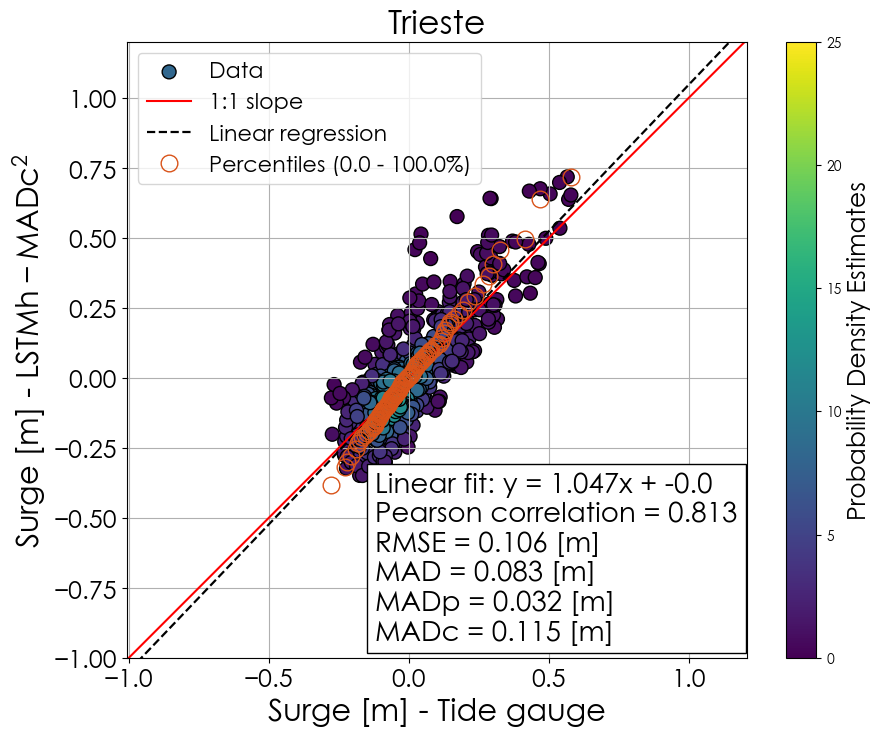

In [79]:
# Density scatter

# Calculate the point density
xy = np.vstack([xr, yr])
z = gaussian_kde(xy)(xy)

plt.rcParams['font.family'] = 'Century Gothic'  # Replace with your preferred font
# Ensure MathText uses the same font
plt.rcParams['mathtext.default'] = 'rm'  # Use the regular font for MathText
plt.rcParams['mathtext.fontset'] = 'custom'  # Enable custom font for MathText
plt.rcParams['mathtext.rm'] = 'Century Gothic'  # Set Roman font for MathText

# For plots
target = 'Tide gauge'
ml_method = r'$\mathrm{LSTMh-MADc}^2$'
#ml_method = r'$\mathrm{MLP-MADc}^2$'
#ml_method = r'$\mathrm{MLR-MADc}^2$'
#ml_method = 'Med-Physics'

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(xr, yr, c=z, cmap='viridis', s=100, edgecolor='k', vmin=0, vmax=25)

# Plot the 1:1 line
ax.plot([lim_inf, lim_sup], [lim_inf, lim_sup], 'r', linewidth=1.5)

# Plot the linear regression line
ax.plot(np.linspace(lim_inf, lim_sup, len(x)), Ysp, '--k', linewidth=1.6)

# Percentiles 
ax.plot(sta_prc, shy_prc, 'o', color='#D95319', linewidth=2, markersize=12, markerfacecolor='none')

# Set labels and titles
ax.set_xlabel(f'Surge [m] - {target}', fontsize=22)
plt.ylabel(f'Surge [m] - {ml_method}', fontsize=22)
ax.set_title('Trieste', fontsize=24)
plt.legend(['Data', '1:1 slope', 'Linear regression', 'Percentiles (0.0 - 100.0%)'], loc='upper left', fontsize=16)

# Set limits and grid
plt.axis('equal')
ax.set_xlim(lim_inf, lim_sup)
ax.set_ylim(lim_inf, lim_sup)
ax.grid(True)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Probability Density Estimates', fontsize=18)

# Customize ticks
ax.tick_params(axis='both', labelsize=18)

# Annotate the plot with statistical details
stats_text = [
    f'Linear fit: y = {round(coeff[1], 3)}x + {round(coeff[0], 5)}',
    f'Pearson correlation = {round(r, 3)}',
    f'RMSE = {round(rmse_test, 3)} [m]',
    f'MAD = {round(mad, 3)} [m]',
    f'MADp = {round(mad_prc, 3)} [m]',
    f'MADc = {round(mad3rd, 3)} [m]'
]
plt.annotate('\n'.join(stats_text), xy=(0.375, 0.12), xycoords='figure fraction', fontsize=20,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='square,pad=0.3'))

# Ensure the axes background is transparent
#ax.set_facecolor('none')

# Set the figure background to be white (outside the plot area)
#fig.patch.set_facecolor('w')

# Clean the method name for the filename
ml_method_clean = (
    ml_method.replace('$', '')  # Remove LaTeX math symbols
    .replace(r'\mathrm{', '')  # Remove the \mathrm{...}
    .replace('}', '')          # Remove closing braces
    .replace('{', '')          # Remove opening braces
    .replace('^', '')          # Remove caret for superscripts
    .replace('-', '_')         # Replace dash with underscore
)

# Generate the filename
filename = f'DS_targetTG_Trieste_{ml_method_clean}_nov2022.png'

# Show the plot
#plt.show()

# Save the figure with transparent axes but white background
plt.savefig(filename, dpi=300, bbox_inches='tight')
